In [1]:
%load_ext autoreload

In [2]:
%autoreload 

import sys
sys.path.append('../../')

import numpy as np
import matplotlib.pyplot as plt

import matplotlib

from plot_params import params
matplotlib.pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
%matplotlib inline

## MACHOs

In [8]:
data_A = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_A.npz') 
data_B = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_B.npz')
data_C = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_C.npz')
data_D = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_D.npz')
data_E = np.load('../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_E.npz')

In [ ]:
data_D

NpzFile '../../data/PBH_dynamical_friction/PBH/power_spec_results/Delt_T21_sq_D.npz' with keys: k_ary, mPBH_ary, fPBH_ary, xi_fft_ary

In [9]:
k_ary = data_A['k_ary']

idx_k_fid = np.abs(k_ary - 0.13).argmin()

In [14]:
mPBH_ary = [] 
f_lim_ary = [] 
for data in [data_A, data_B, data_C, data_E]:
    delt2_at_k_fid = data['xi_fft_ary'][idx_k_fid, :, :]*1e6  # shape (len(mPBH_ary), len(fPBH_ary))
    for i,mPBH in enumerate(data['mPBH_ary']): 
        mPBH_ary.append(mPBH)
        print(mPBH, delt2_at_k_fid[i])
        f_lim = 10**np.interp(np.log10(92.7), np.log10(delt2_at_k_fid[i]), np.log10(data['fPBH_ary']), left=np.nan, right=0.)
        f_lim_ary.append(f_lim)
        print(mPBH, f_lim)

10.0 [0.00274534 0.0109512  0.06785008 0.15148648 0.2671554 ]
10.0 1.0
20.0 [0.00921376 0.03664092 0.22487912 0.49810171 0.87149063]
20.0 1.0
50.0 [0.04445803 0.17529001 1.04887648 2.27654503 3.90797328]
50.0 1.0
80.0 [0.09822286 0.38432311 2.25110034 4.8072822  8.12066275]
80.0 1.0
100.0 [ 0.14253499  0.85602887  3.20998479  6.78423656 11.34848308]
100.0 1.0
200.0 [ 0.44502205  2.59137247  9.26111062 18.72191921 30.0421637 ]
200.0 1.0
500.0 [ 1.89381375 10.21565941 32.58931133 59.60493217 87.4983087 ]
500.0 1.0
800.0 [  3.83424008  19.41174695  56.69770207  96.4834052  133.24165731]
800.0 0.7274638915497128
1000.0 [  1.44677249   3.11213425   5.29405723  25.81801875  71.75669052
 117.43825207 157.07088846]
1000.0 0.6173173571057904
2000.0 [  3.92178618   8.17914309  13.51022692  56.66290917 131.04064973
 187.3624525  225.74281751]
2000.0 0.3755656976358957
5000.0 [ 13.08374817  25.64149479  39.99332844 128.18898507 223.18993549
 266.19409097 282.06976402]
5000.0 0.1937321752281224
800

(1e-05, 1)

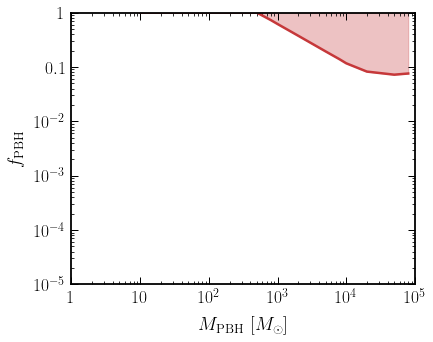

In [17]:
plt.figure() 

plt.loglog(np.array(mPBH_ary), np.array(f_lim_ary), alpha=1.) 
plt.fill_between(np.array(mPBH_ary), np.array(f_lim_ary), 1, color='C0', alpha=0.3)

plt.xlabel(r'$M_{\mathrm{PBH}}$ [$M_\odot$]')
plt.ylabel(r'$f_{\mathrm{PBH}}$')
plt.xlim(1, 1e5)
plt.ylim(1e-5, 1)

In [28]:
np.transpose((mPBH_ary, f_lim_ary))

array([[1.00000000e+01, 1.00000000e+00],
       [2.00000000e+01, 1.00000000e+00],
       [5.00000000e+01, 1.00000000e+00],
       [8.00000000e+01, 1.00000000e+00],
       [1.00000000e+02, 1.00000000e+00],
       [2.00000000e+02, 1.00000000e+00],
       [5.00000000e+02, 1.00000000e+00],
       [8.00000000e+02, 7.27463892e-01],
       [1.00000000e+03, 6.17317357e-01],
       [2.00000000e+03, 3.75565698e-01],
       [5.00000000e+03, 1.93732175e-01],
       [8.00000000e+03, 1.38680571e-01],
       [1.00000000e+04, 1.16926955e-01],
       [2.00000000e+04, 8.22083892e-02],
       [5.00000000e+04, 7.21364407e-02],
       [8.00000000e+04, 7.58164491e-02]])

## Axion Miniclusters

In [18]:
# ONE, TWO, THREE, and FOUR correspond to the characteristic mass of the axion miniclusters (m_{h,c}) in units of solar masses.
# ONE = 1e-2, TWO = 1e-1, THREE = 1, FOUR = 1e-3 MSolar

data_O = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_O.npz') 
data_P = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_P.npz')
data_Q = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_Q.npz')
data_R = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_R.npz') 
data_S = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_S.npz')
data_T = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_T.npz')
data_V = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_V.npz')
data_Z = np.load('../../data/PBH_dynamical_friction/axion_miniclusters/power_spec_results/Delt_T21_sq_Z.npz')

In [19]:
k_ary = data_O['k_ary']

idx_k_fid = np.abs(k_ary - 0.13).argmin()

In [22]:
delt2_at_k_ary = [] 
for data in [data_O, data_P, data_Q, data_R, data_S, data_T, data_V, data_Z]:
    delt2_at_k_fid = data['xi_fft_ary'][idx_k_fid]*1e6  
    delt2_at_k_ary.append(delt2_at_k_fid)

m_h_lim = 10**np.interp(np.log10(92.7), np.log10(delt2_at_k_ary), np.log10([1e-3, 2e-3, 5e-3, 8e-3, 1e-2, 2e-2, 5e-2, 1e-1]), left=np.nan, right=np.nan)

print(m_h_lim)

0.014797951512460205


[[1.00000000e-21 5.58541144e-22]
 [5.99484250e-20 3.34836619e-20]
 [3.59381366e-18 2.00729280e-18]
 [2.15443469e-16 1.20334042e-16]
 [1.29154967e-14 7.21383628e-15]
 [7.74263683e-13 4.32458123e-13]
 [4.64158883e-11 2.59251834e-11]
 [2.78255940e-09 1.55417391e-09]
 [1.66810054e-07 9.31702783e-08]
 [1.00000000e-05 5.58541144e-06]]


(1e-24, 1e-09)

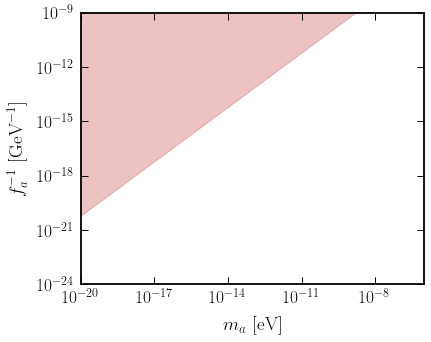

In [35]:
plt.figure() 

ma_ary = np.logspace(-21, -5, 10)
fa_lim_ary = 1e11 * ( 
    (m_h_lim / 1.5e-12 * (ma_ary / 1e-6)**2 * (10/100)**(0.5))**(-0.5)
)
print(np.transpose((ma_ary, 1. / fa_lim_ary)))

plt.fill_between(ma_ary, 1. / fa_lim_ary, 1., color='C0', alpha=0.3)

plt.loglog()

plt.xlabel(r'$m_a$ [eV]')
plt.ylabel(r'$f_a^{-1}$ [GeV$^{-1}$]')

plt.xlim(1e-20, 1e-6)
plt.ylim(1e-24, 1e-9)

In [34]:
print(np.array(np.transpose((ma_ary, 1. / fa_lim_ary))))

[[1.00000000e-21 9.93242217e-22]
 [5.99484250e-20 5.95433066e-20]
 [3.59381366e-18 3.56952745e-18]
 [2.15443469e-16 2.13987549e-16]
 [1.29154967e-14 1.28282165e-14]
 [7.74263683e-13 7.69031376e-13]
 [4.64158883e-11 4.61022198e-11]
 [2.78255940e-09 2.76375547e-09]
 [1.66810054e-07 1.65682788e-07]
 [1.00000000e-05 9.93242217e-06]]
